In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("data/final.csv")
df.head(5)

,isbn,title,plot,book_subjectivity,book_polarity,authors,publisher,published_date,genre,year_published,...,review/topic,review/subjectivity,review/polarity,review/score,review/helpfulness,review/time,year_reviewed,month_reviewed,day_reviewed,profile_name
0,0802841899,The Church of Christ: A Biblical Ecclesiology ...,In The Church of Christ: A Biblical Ecclesiolo...,0.692424,0.172727,['Everett Ferguson'],Wm. B. Eerdmans Publishing,1996,['Religion'],1996,...,-1,0.504196,0.180887,5.0,74/81,2000-04-11,2000,4,11,Christopher J. Bray
1,0802841899,The Church of Christ: A Biblical Ecclesiology ...,In The Church of Christ: A Biblical Ecclesiolo...,0.692424,0.172727,['Everett Ferguson'],Wm. B. Eerdmans Publishing,1996,['Religion'],1996,...,-1,0.483222,0.050111,5.0,2/3,2011-07-24,2011,7,24,haskell
2,0802841899,The Church of Christ: A Biblical Ecclesiology ...,In The Church of Christ: A Biblical Ecclesiolo...,0.692424,0.172727,['Everett Ferguson'],Wm. B. Eerdmans Publishing,1996,['Religion'],1996,...,-1,0.664286,0.425000,4.0,2/3,2010-11-17,2010,11,17,GodsBreath.wordpress
3,0802841899,The Church of Christ: A Biblical Ecclesiology ...,In The Church of Christ: A Biblical Ecclesiolo...,0.692424,0.172727,['Everett Ferguson'],Wm. B. Eerdmans Publishing,1996,['Religion'],1996,...,1411,0.050000,0.295000,4.0,3/5,2010-02-15,2010,2,15,Edward E. Howe
4,0887402216,The Battleship Bismarck,The Bismarck is perhaps the most famous – and ...,0.426673,0.217551,['Stefan Draminski'],Especializadas,2018-09-20,['History'],2018,...,506,0.266667,0.135618,3.0,9/9,2003-06-19,2003,6,19,Lawrence Duckles


In [3]:
df.columns

Index(['isbn', 'title', 'plot', 'book_subjectivity', 'book_polarity',
       'authors', 'publisher', 'published_date', 'genre', 'year_published',
       'month', 'month_name', 'price', 'cover', 'color_rgb', 'color',
       'user_id', 'ratings_count', 'review/summary', 'review/text',
       'review/topic', 'review/subjectivity', 'review/polarity',
       'review/score', 'review/helpfulness', 'review/time', 'year_reviewed',
       'month_reviewed', 'day_reviewed', 'profile_name'],
      dtype='object')

In [4]:
# Primero, dibujaremos el mapa de relaciones para comprobar cuáles son los vínculos más fuertes de nuestras variables. 
# Para ello, primero pasaremos con one hot encoding las columnas categóricas
df_encoded = df.copy()
cols_categoricas = [
    'authors', 'publisher', 'genre', 'month_name', 
    'color', 'profile_name', 'review/topic'
]

In [5]:
le = LabelEncoder()
for col in cols_categoricas:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [6]:
# Incluimos el resto de columnas
df_final = df_encoded.select_dtypes(include=['number'])

In [7]:
plt.figure(figsize=(20, 15))
corr_matrix = df_final.corr()

<Figure size 2000x1500 with 0 Axes>

<Axes: >

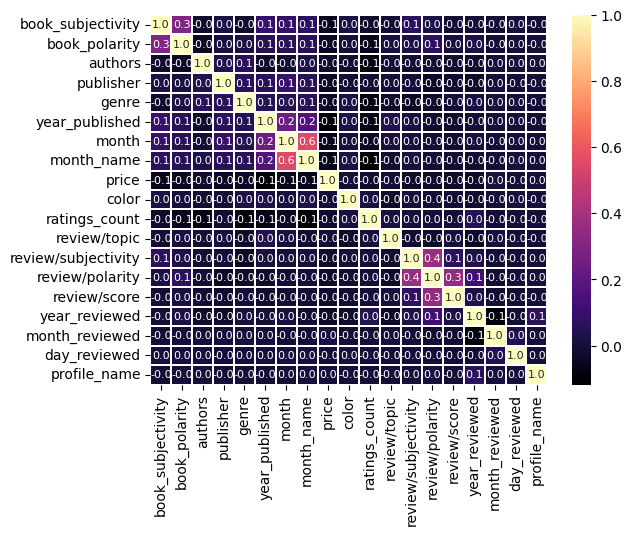

In [8]:
# Hacemos la visualización
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".1f",      
    cmap='magma',    
    linewidths=.2,
    annot_kws={"size": 8}
)

In [9]:
# Agrupamos por libro para tener el perfil medio de cada uno
df_ml = df.groupby('title').agg({
    'book_subjectivity': 'first',
    'book_polarity': 'first',
    'year_published': 'first',
    'publisher': 'first',
    'genre': 'first',
    'review/subjectivity': 'mean',
    'review/polarity': 'mean',
    'ratings_count': 'max'
}).reset_index()


In [10]:
# Convertimos publisher y genre a Dummies (como en el sistema de asociaciones)
df_vectors = pd.get_dummies(df_ml, columns=['publisher', 'genre'])

In [11]:
# Escalamos: Es vital para que el año o los ratings no "aplasten" a la polaridad
scaler = MinMaxScaler()
cols_to_scale = ['book_subjectivity', 'book_polarity', 'year_published', 
                 'review/subjectivity', 'review/polarity', 'ratings_count']
df_vectors[cols_to_scale] = scaler.fit_transform(df_vectors[cols_to_scale])

In [12]:
# Definimos las columnas que usará el modelo
features_columns = df_vectors.drop(columns=['title']).columns

In [13]:
# Entrenamos el modelo con toda nuestro df
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(df_vectors[features_columns])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [14]:
def recomendador():
    print("¿Qué libro deberías leer?")
    
    # INPUTS USUARIO
    gen = input("¿Qué género buscas? (ej: ficción, romance): ")
    pub = input("¿Alguna editorial preferida? (o presiona Enter): ")
    yr = int(input("¿Año de publicación aproximado?: "))

    while True:
        print("\n¿Qué prefieres descubrir?")
        print("1. Bestsellers (Libros muy conocidos)")
        print("2. Joyas ocultas (Libros poco conocidos)")
        pop_choice = input("Elige una opción (1-2): ")
        
        if pop_choice in ['1', '2']:
            break
        else:
            print("Error: Por favor, escribe solo '1' o '2'.")

    while True:
        try:
            print("\nDefine el tono emocional del libro:")
            print("Rango: [-1.0 (Muy Triste) a 1.0 (Muy Feliz)]")
            entrada = float(input("Introduce la polaridad: "))
            
            if -1.0 <= entrada <= 1.0:
                polaridad_target = entrada
                break  
            else:
                print("Error: El número debe estar entre -1.0 y 1.0. Inténtalo de nuevo.")
        except ValueError:
            print("Error: Por favor, introduce un número decimal válido (ejemplo: 0.5 o -0.2).")
    
    
    user_query = pd.DataFrame(0, index=[0], columns=features_columns)
    user_query['ratings_count'] = 1.0 if pop_choice == '1' else 0.0
    user_query['book_polarity'] = polaridad_target
    user_query['book_subjectivity'] = 0.5 
    user_query['year_published'] = (yr - df['year_published'].min()) / (df['year_published'].max() - df['year_published'].min())
    user_query['review/polarity'] = 0.9 
    

    if f'genre_{gen}' in user_query.columns:
        user_query[f'genre_{gen}'] = 1
    if f'publisher_{pub}' in user_query.columns:
        user_query[f'publisher_{pub}'] = 1
        
  
    distancias, indices = model_knn.kneighbors(user_query, n_neighbors=5)
    
    print(f"\n✨ RECOMENDÁNDOTE {'BESTSELLERS' if pop_choice == '1' else 'JOYAS OCULTAS'}:")
    for i, idx in enumerate(indices[0], 1):
        libro = df_ml.iloc[idx]
    
        print(f"{i}. {libro['title']} ({int(libro['year_published'])})")
        print(f"   [Popularidad: {int(libro['ratings_count'])} ratings | Coincidencia: {round((1-distancias[0][i-1])*100, 2)}%]")


In [15]:
recomendador()

¿Qué libro deberías leer?

¿Qué prefieres descubrir?
1. Bestsellers (Libros muy conocidos)
2. Joyas ocultas (Libros poco conocidos)

Define el tono emocional del libro:
Rango: [-1.0 (Muy Triste) a 1.0 (Muy Feliz)]

✨ RECOMENDÁNDOTE BESTSELLERS:
1. Legends & Legacies: Celebrating a Century of Minnesota Coaches (2013)
   [Popularidad: 2692 ratings | Coincidencia: 82.59%]
2. 2176: Birth of the Belt Republic (Belt Republic, Book 1) (2013)
   [Popularidad: 2692 ratings | Coincidencia: 82.42%]
3. Legend (2013)
   [Popularidad: 2692 ratings | Coincidencia: 80.92%]
4. Sense and Sensibility (2003)
   [Popularidad: 2409 ratings | Coincidencia: 80.59%]
5. The Signature of All Things (2014)
   [Popularidad: 1884 ratings | Coincidencia: 80.26%]


In [23]:
# Además de esto, creo que para nuestro análisis puede ser interesante clasificar las experiencias mediante un thhreshold (también está en SQL):
 # Calculamos la diferencia: Reseña - Sinopsis
    # Un valor positivo alto = El usuario lo disfrutó más que la promesa inicial
    # Un valor negativo alto = La sinopsis prometía más de lo que el usuario sintió

def clasificar_experiencia(row, umbral=0.15):
    diferencia = row['review/polarity'] - row['book_polarity']
    if diferencia > umbral:
        return 'Sorpresa'
    elif diferencia < -umbral:
        return 'Decepción'
    else:
        return 'Expectativa cumplida'

In [24]:
df['experiencia_tipo'] = df.apply(clasificar_experiencia, axis=1)
print(df[['title', 'book_polarity', 'review/polarity', 'experiencia_tipo']].head())


                                               title  book_polarity  \
0  The Church of Christ: A Biblical Ecclesiology ...       0.172727   
1  The Church of Christ: A Biblical Ecclesiology ...       0.172727   
2  The Church of Christ: A Biblical Ecclesiology ...       0.172727   
3  The Church of Christ: A Biblical Ecclesiology ...       0.172727   
4                            The Battleship Bismarck       0.217551   

   review/polarity      experiencia_tipo  
0         0.180887  Expectativa cumplida  
1         0.050111  Expectativa cumplida  
2         0.425000              Sorpresa  
3         0.295000  Expectativa cumplida  
4         0.135618  Expectativa cumplida  


/var/folders/bk/hzstscb16rn4p883jsg8t31c0000gn/T/ipykernel_19824/3443569688.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='experiencia_tipo', palette='magma')


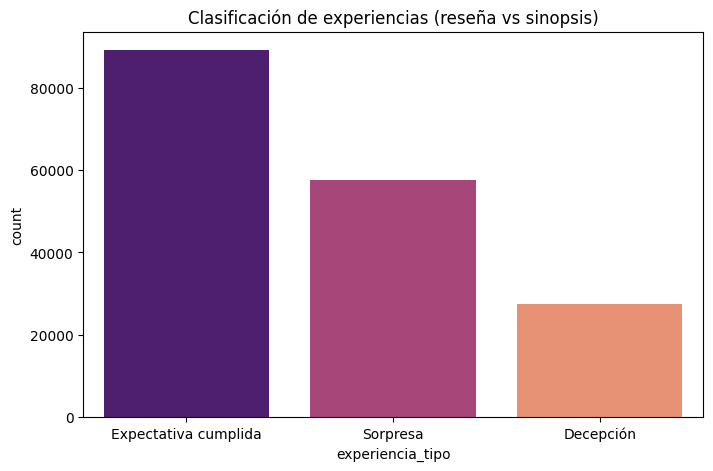

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='experiencia_tipo', palette='magma')
plt.title('Clasificación de experiencias (reseña vs sinopsis)')
plt.show()